# Weather Data Extraction and Exploration Using Meteoblue API

This notebook extracts weather data from the Meteoblue API for a selected project location and explores the raw JSON response.

Project location:

- Location ID: LOC001
- Location Name: Greensboro_NC
- Latitude: 36.142715
- Longitude: -79.883133

The extracted raw API response will be saved in the `data/raw` folder and later transformed into a structured dataset for weather forecasting.

## Import Required Libraries

In this step, we import the Python libraries needed for data extraction and exploration.

- `os`, `sys`, and `Path` help manage file paths.
- `json` is used to read and inspect the raw API response.
- `pandas` and `numpy` are used for data handling and analysis.

In [1]:
import os
import sys
import json
from pathlib import Path

import pandas as pd
import numpy as np

print("Libraries imported successfully.")

Libraries imported successfully.


## Set Project Path and Connect to Source Folder

In this step, we define the root folder of the project. This helps the notebook locate project files such as configuration files, input data, raw API responses, and source code.

We also add the `src` folder to the Python path so that the notebook can import reusable Python files such as `load_config.py` and `meteoblue_client.py`.

In [2]:
# Define the project root folder
PROJECT_ROOT = Path(r"C:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Project_Weather_Forecast_Model")

# Define the source folder path
SRC_DIR = PROJECT_ROOT / "src"

# Add src folder to Python path if it is not already added
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

print("Project root:")
print(PROJECT_ROOT)

print("\nSource directory:")
print(SRC_DIR)

print("\nSource directory exists:", SRC_DIR.exists())

Project root:
C:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Project_Weather_Forecast_Model

Source directory:
C:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Project_Weather_Forecast_Model\src

Source directory exists: True


## Load Project Configuration, Location, and API Key

In this step, we use the reusable helper functions from `load_config.py`.

This cell loads three important inputs:

1. The YAML configuration file from `config/meteoblue_config.yaml`
2. The location details from `data/input/location_master.csv`
3. The Meteoblue API key from the local `.env` file

The API key is loaded from `.env` so that it is not hardcoded directly inside the notebook.

In [3]:
from load_config import load_yaml_config, load_location_master, load_api_key

# Load project configuration
config = load_yaml_config()

# Load location master file
locations_df = load_location_master()

# Load Meteoblue API key
api_key = load_api_key()

print("Config loaded successfully.")
print("Location master loaded successfully.")
print("API key loaded successfully.")
print("API key length:", len(api_key))

display(locations_df)

Config loaded successfully.
Location master loaded successfully.
API key loaded successfully.
API key length: 16


,location_id,location_name,latitude,longitude,country,state
0,LOC001,Greensboro_NC,36.142715,-79.883133,USA,NC


## Run Meteoblue API Extraction

In this step, we call the Meteoblue API for the selected location.

The function `extract_weather_for_first_location()` comes from `meteoblue_client.py`. It performs the following tasks:

1. Reads the first location from `location_master.csv`
2. Builds the API request using latitude and longitude
3. Calls the Meteoblue `basic-day` API
4. Saves the raw JSON response into the `data/raw` folder

This creates the raw source file that we will inspect and transform in the next steps.

In [5]:
from meteoblue_client import extract_weather_for_first_location

# Run API extraction for the first location
response_json, raw_output_file = extract_weather_for_first_location()

print("\nExtraction completed.")
print("Raw output file:")
print(raw_output_file)

Starting Meteoblue extraction
Location ID: LOC001
Location Name: Greensboro_NC
Latitude: 36.142715
Longitude: -79.883133
Base URL: https://my.meteoblue.com/packages/basic-day
API Status Code: 200
API URL: https://my.meteoblue.com/packages/basic-day?lat=36.142715&lon=-79.883133&apikey=****&format=json

Raw API response saved successfully:
C:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Project_Weather_Forecast_Model\data\raw\meteoblue_basic_day_LOC001.json

Extraction completed.
Raw output file:
C:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Project_Weather_Forecast_Model\data\raw\meteoblue_basic_day_LOC001.json


## Inspect Raw JSON Structure

After extracting the Meteoblue API response, the next step is to inspect the structure of the raw JSON object.

This helps us understand what sections are available in the API response. We need to identify where the actual daily weather data is stored before converting it into a structured DataFrame.

In [6]:
# Check the Python object type returned from the API
print("Type of response_json:", type(response_json))

# Display the top-level keys available in the JSON response
print("\nTop-level keys:")
print(list(response_json.keys()))

Type of response_json: <class 'dict'>

Top-level keys:
['metadata', 'units', 'data_day']


## Explore Metadata, Units, and Daily Weather Fields

The raw API response contains three main sections:

- `metadata`: provides information about the API response and location.
- `units`: provides measurement units for weather variables.
- `data_day`: contains the daily weather observations and forecast variables.

In this step, we inspect the keys inside each section so we can understand what fields are available for analysis and modeling.

In [7]:
# Inspect keys inside each main section
print("Metadata keys:")
print(list(response_json["metadata"].keys()))

print("\nUnits keys:")
print(list(response_json["units"].keys()))

print("\nDaily data keys:")
print(list(response_json["data_day"].keys()))

Metadata keys:
['modelrun_updatetime_utc', 'name', 'height', 'timezone_abbrevation', 'latitude', 'modelrun_utc', 'longitude', 'utc_timeoffset', 'generation_time_ms']

Units keys:
['predictability', 'precipitation', 'windspeed', 'precipitation_probability', 'relativehumidity', 'time', 'temperature', 'pressure', 'winddirection']

Daily data keys:
['time', 'temperature_instant', 'precipitation', 'predictability', 'temperature_max', 'sealevelpressure_mean', 'windspeed_mean', 'precipitation_hours', 'sealevelpressure_min', 'pictocode', 'snowfraction', 'humiditygreater90_hours', 'convective_precipitation', 'relativehumidity_max', 'temperature_min', 'winddirection', 'felttemperature_max', 'relativehumidity_min', 'felttemperature_mean', 'windspeed_min', 'felttemperature_min', 'precipitation_probability', 'uvindex', 'rainspot', 'temperature_mean', 'sealevelpressure_max', 'relativehumidity_mean', 'predictability_class', 'windspeed_max']


## Convert Daily Weather Data into a DataFrame

The `data_day` section contains the actual daily weather values returned by the Meteoblue API.

Each key inside `data_day` represents a weather variable, and each variable contains a list of daily values. In this step, we convert this dictionary-style JSON structure into a pandas DataFrame so that the data can be analyzed, cleaned, and later used for forecasting.

In [8]:
# Convert the daily weather section into a pandas DataFrame
daily_weather_df = pd.DataFrame(response_json["data_day"])

print("Daily weather DataFrame created successfully.")
print("Shape:", daily_weather_df.shape)

display(daily_weather_df.head())

Daily weather DataFrame created successfully.
Shape: (7, 29)


,time,temperature_instant,precipitation,predictability,temperature_max,sealevelpressure_mean,windspeed_mean,precipitation_hours,sealevelpressure_min,pictocode,...,windspeed_min,felttemperature_min,precipitation_probability,uvindex,rainspot,temperature_mean,sealevelpressure_max,relativehumidity_mean,predictability_class,windspeed_max
0,2026-06-13,25.69,0.00,71,34.03,1013,2.34,0.0,1012,2,...,1.67,23.11,7,9,0121000001000000000000000000000000000000000000000,27.26,1015,72,4.0,3.43
1,2026-06-14,25.01,2.61,53,35.74,1010,3.70,8.0,1006,8,...,1.82,26.14,37,9,2222223222222322222232222223222222222222222222222,28.58,1013,66,3.0,5.65
2,2026-06-15,24.58,0.00,74,29.78,1011,3.69,0.0,1008,2,...,2.62,21.05,8,10,3322100231010911000001000000000000000000000000000,25.30,1012,57,4.0,4.67
3,2026-06-16,22.07,0.00,62,29.14,1010,3.29,0.0,1008,3,...,2.52,18.58,6,6,0000001000000900000010000001000000100000000000000,23.60,1012,58,4.0,3.77
4,2026-06-17,20.29,1.84,54,31.88,1009,3.79,6.0,1008,8,...,2.93,18.99,21,9,2222222211112222111113222211322222132222222222221,25.28,1010,60,3.0,4.84


## Inspect Data Types and Missing Values

Before using the weather data for analysis or modeling, we inspect the structure of the DataFrame.

This step checks:

- The data type of each column
- Whether numeric weather fields are stored correctly
- Whether any columns contain missing values

This helps identify whether cleaning is required before saving the API response as a structured dataset.

In [9]:
# Display column names and data types
print("Data types:")
display(daily_weather_df.dtypes)

# Check missing values
missing_summary = daily_weather_df.isna().sum().reset_index()
missing_summary.columns = ["column", "missing_count"]
missing_summary["missing_percentage"] = (
    missing_summary["missing_count"] / len(daily_weather_df)
) * 100

print("Missing value summary:")
display(missing_summary)

Data types:


time                          object
temperature_instant          float64
precipitation                float64
predictability                 int64
temperature_max              float64
sealevelpressure_mean          int64
windspeed_mean               float64
precipitation_hours          float64
sealevelpressure_min           int64
pictocode                      int64
snowfraction                 float64
humiditygreater90_hours      float64
convective_precipitation     float64
relativehumidity_max           int64
temperature_min              float64
winddirection                  int64
felttemperature_max          float64
relativehumidity_min           int64
felttemperature_mean         float64
windspeed_min                float64
felttemperature_min          float64
precipitation_probability      int64
uvindex                        int64
rainspot                      object
temperature_mean             float64
sealevelpressure_max           int64
relativehumidity_mean          int64
p

Missing value summary:


,column,missing_count,missing_percentage
0,time,0,0.0
1,temperature_instant,0,0.0
2,precipitation,0,0.0
3,predictability,0,0.0
4,temperature_max,0,0.0
5,sealevelpressure_mean,0,0.0
6,windspeed_mean,0,0.0
7,precipitation_hours,0,0.0
8,sealevelpressure_min,0,0.0
9,pictocode,0,0.0


## Clean Date Column and Add Location Details

In this step, we prepare the daily weather DataFrame for analysis and modeling.

The `time` column is converted into a proper datetime format. We also add location-related columns such as `location_id`, `location_name`, `latitude`, and `longitude` so that the dataset clearly identifies the geographic location used for the API extraction.

In [10]:
# Create a copy of the daily weather data
weather_df = daily_weather_df.copy()

# Convert time column to datetime
weather_df["time"] = pd.to_datetime(weather_df["time"])

# Add location details from the location master file
location_row = locations_df.iloc[0]

weather_df["location_id"] = location_row["location_id"]
weather_df["location_name"] = location_row["location_name"]
weather_df["latitude"] = location_row["latitude"]
weather_df["longitude"] = location_row["longitude"]

# Sort by date
weather_df = weather_df.sort_values("time").reset_index(drop=True)

print("Weather data cleaned successfully.")
print("Shape:", weather_df.shape)

display(weather_df.head())

Weather data cleaned successfully.
Shape: (7, 33)


,time,temperature_instant,precipitation,predictability,temperature_max,sealevelpressure_mean,windspeed_mean,precipitation_hours,sealevelpressure_min,pictocode,...,rainspot,temperature_mean,sealevelpressure_max,relativehumidity_mean,predictability_class,windspeed_max,location_id,location_name,latitude,longitude
0,2026-06-13,25.69,0.00,71,34.03,1013,2.34,0.0,1012,2,...,0121000001000000000000000000000000000000000000000,27.26,1015,72,4.0,3.43,LOC001,Greensboro_NC,36.142715,-79.883133
1,2026-06-14,25.01,2.61,53,35.74,1010,3.70,8.0,1006,8,...,2222223222222322222232222223222222222222222222222,28.58,1013,66,3.0,5.65,LOC001,Greensboro_NC,36.142715,-79.883133
2,2026-06-15,24.58,0.00,74,29.78,1011,3.69,0.0,1008,2,...,3322100231010911000001000000000000000000000000000,25.30,1012,57,4.0,4.67,LOC001,Greensboro_NC,36.142715,-79.883133
3,2026-06-16,22.07,0.00,62,29.14,1010,3.29,0.0,1008,3,...,0000001000000900000010000001000000100000000000000,23.60,1012,58,4.0,3.77,LOC001,Greensboro_NC,36.142715,-79.883133
4,2026-06-17,20.29,1.84,54,31.88,1009,3.79,6.0,1008,8,...,2222222211112222111113222211322222132222222222221,25.28,1010,60,3.0,4.84,LOC001,Greensboro_NC,36.142715,-79.883133


## Save Cleaned Weather Dataset

After cleaning the Meteoblue daily weather data and adding location details, we save the structured dataset as a CSV file.

This file will be used as the input dataset for exploratory analysis and the prototype forecasting model.

In [11]:
# Define output folder and file path
output_dir = PROJECT_ROOT / "data" / "output"
output_dir.mkdir(parents=True, exist_ok=True)

weather_output_file = output_dir / "weather_basic_day_cleaned_LOC001.csv"

# Save cleaned weather data
weather_df.to_csv(weather_output_file, index=False)

print("Cleaned weather dataset saved successfully.")
print("Output file:")
print(weather_output_file)

Cleaned weather dataset saved successfully.
Output file:
C:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Project_Weather_Forecast_Model\data\output\weather_basic_day_cleaned_LOC001.csv


## Select Key Weather Columns for Analysis

The Meteoblue API response contains many daily weather variables. For this prototype forecasting project, we select the most relevant columns for analysis and modeling.

The selected variables include:

- `temperature_mean`: average daily temperature
- `temperature_min`: minimum daily temperature
- `temperature_max`: maximum daily temperature
- `precipitation`: daily precipitation
- `relativehumidity_mean`: average daily relative humidity
- `windspeed_mean`: average daily wind speed
- `sealevelpressure_mean`: average daily sea-level pressure

These variables are useful because they describe the main weather conditions for each day.

In [12]:
# Select important columns for analysis and modeling
selected_columns = [
    "time",
    "location_id",
    "location_name",
    "latitude",
    "longitude",
    "temperature_mean",
    "temperature_min",
    "temperature_max",
    "precipitation",
    "relativehumidity_mean",
    "windspeed_mean",
    "sealevelpressure_mean",
    "precipitation_probability",
    "uvindex"
]

weather_selected_df = weather_df[selected_columns].copy()

print("Selected weather dataset created successfully.")
print("Shape:", weather_selected_df.shape)

display(weather_selected_df)

Selected weather dataset created successfully.
Shape: (7, 14)


,time,location_id,location_name,latitude,longitude,temperature_mean,temperature_min,temperature_max,precipitation,relativehumidity_mean,windspeed_mean,sealevelpressure_mean,precipitation_probability,uvindex
0,2026-06-13,LOC001,Greensboro_NC,36.142715,-79.883133,27.26,20.56,34.03,0.00,72,2.34,1013,7,9
1,2026-06-14,LOC001,Greensboro_NC,36.142715,-79.883133,28.58,23.59,35.74,2.61,66,3.70,1010,37,9
2,2026-06-15,LOC001,Greensboro_NC,36.142715,-79.883133,25.30,21.57,29.78,0.00,57,3.69,1011,8,10
3,2026-06-16,LOC001,Greensboro_NC,36.142715,-79.883133,23.60,19.97,29.14,0.00,58,3.29,1010,6,6
4,2026-06-17,LOC001,Greensboro_NC,36.142715,-79.883133,25.28,18.87,31.88,1.84,60,3.79,1009,21,9
5,2026-06-18,LOC001,Greensboro_NC,36.142715,-79.883133,28.40,22.52,36.28,0.00,66,6.44,1009,43,9
6,2026-06-19,LOC001,Greensboro_NC,36.142715,-79.883133,26.38,22.55,31.60,9.37,77,5.47,1009,72,9


## Visualize Temperature Trend

In this step, we create a line chart to visualize the daily average temperature trend for the selected location.

Even though the current dataset contains only seven forecast days, this visualization helps us understand how the average temperature changes over the forecast period.

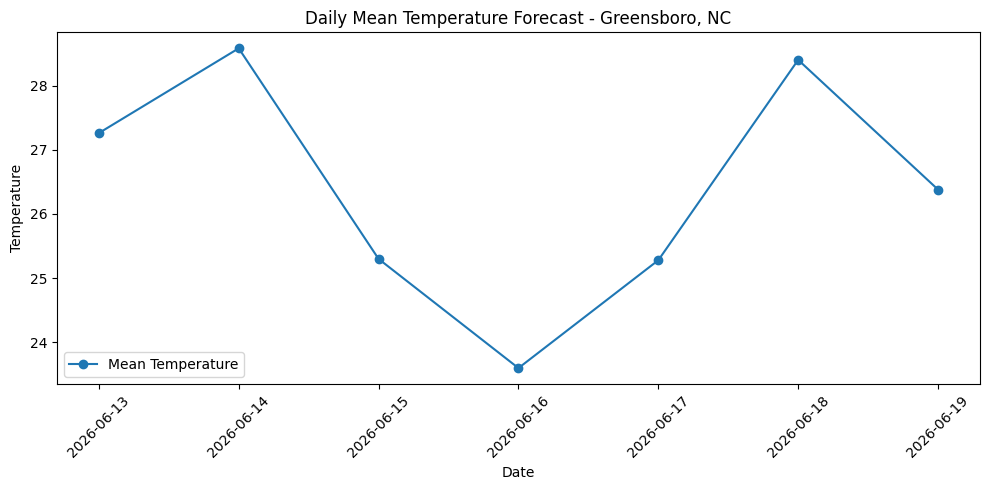

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(
    weather_selected_df["time"],
    weather_selected_df["temperature_mean"],
    marker="o",
    label="Mean Temperature"
)

plt.title("Daily Mean Temperature Forecast - Greensboro, NC")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Visualize Precipitation Trend

In this step, we visualize the daily precipitation forecast for the selected location.

Precipitation is important because it helps identify expected rainfall patterns during the forecast period. This variable can also be useful later as an input feature for weather forecasting models.

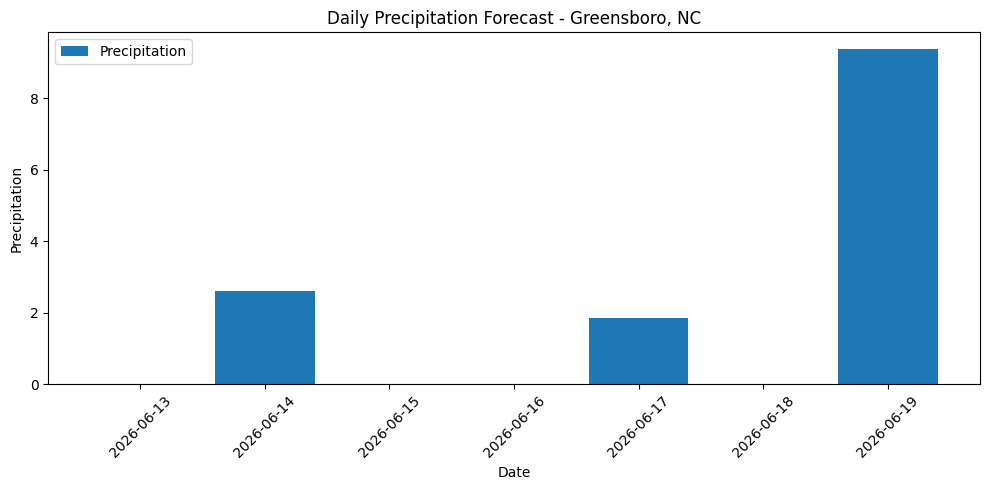

In [14]:
plt.figure(figsize=(10, 5))
plt.bar(
    weather_selected_df["time"],
    weather_selected_df["precipitation"],
    label="Precipitation"
)

plt.title("Daily Precipitation Forecast - Greensboro, NC")
plt.xlabel("Date")
plt.ylabel("Precipitation")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Analyze Relationships Between Weather Variables

In this step, we calculate the correlation between selected numeric weather variables.

Correlation helps us understand how weather variables move together. For example, temperature may have a relationship with humidity, precipitation, wind speed, or pressure.

This analysis is useful before modeling because it helps identify which variables may be helpful as input features.

In [15]:
# Select numeric columns for correlation analysis
correlation_columns = [
    "temperature_mean",
    "temperature_min",
    "temperature_max",
    "precipitation",
    "relativehumidity_mean",
    "windspeed_mean",
    "sealevelpressure_mean",
    "precipitation_probability",
    "uvindex"
]

correlation_df = weather_selected_df[correlation_columns].corr()

print("Correlation matrix:")
display(correlation_df)

Correlation matrix:


,temperature_mean,temperature_min,temperature_max,precipitation,relativehumidity_mean,windspeed_mean,sealevelpressure_mean,precipitation_probability,uvindex
temperature_mean,1.000000,0.713767,0.953617,0.091986,0.541541,0.352996,0.038862,0.456467,0.534321
temperature_min,0.713767,1.000000,0.536483,0.355818,0.438623,0.483006,-0.141615,0.615157,0.353157
temperature_max,0.953617,0.536483,1.000000,-0.051984,0.441685,0.329024,-0.021413,0.357210,0.362984
precipitation,0.091986,0.355818,-0.051984,1.000000,0.677087,0.391649,-0.437264,0.844196,0.152924
relativehumidity_mean,0.541541,0.438623,0.441685,0.677087,1.000000,0.267261,0.074247,0.687586,0.237155
windspeed_mean,0.352996,0.483006,0.329024,0.391649,0.267261,1.000000,-0.746805,0.768636,0.194283
sealevelpressure_mean,0.038862,-0.141615,-0.021413,-0.437264,0.074247,-0.746805,1.000000,-0.624829,0.116775
precipitation_probability,0.456467,0.615157,0.357210,0.844196,0.687586,0.768636,-0.624829,1.000000,0.246052
uvindex,0.534321,0.353157,0.362984,0.152924,0.237155,0.194283,0.116775,0.246052,1.000000


## Save Correlation Matrix

The correlation matrix is saved as a CSV file so it can be reused later in the project report.

This output helps document the relationship between important weather variables such as temperature, humidity, precipitation, wind speed, and pressure.

In [16]:
# Define metrics output folder
metrics_dir = PROJECT_ROOT / "outputs" / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)

# Save correlation matrix
correlation_output_file = metrics_dir / "weather_variable_correlation_matrix.csv"
correlation_df.to_csv(correlation_output_file)

print("Correlation matrix saved successfully.")
print("Output file:")
print(correlation_output_file)

Correlation matrix saved successfully.
Output file:
C:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Project_Weather_Forecast_Model\outputs\metrics\weather_variable_correlation_matrix.csv


## Create Forecasting Target Variable

For this prototype weather forecasting model, the target variable is the next day's average temperature.

The current day's weather variables will be used as input features, and the model will try to predict the following day's `temperature_mean`.

This is created by shifting the `temperature_mean` column upward by one row.

In [17]:
# Create a modeling DataFrame
model_df = weather_selected_df.copy()

# Create next-day temperature target
model_df["target_next_day_temperature_mean"] = model_df["temperature_mean"].shift(-1)

# Remove the final row because it has no next-day target
model_df = model_df.dropna().reset_index(drop=True)

print("Modeling dataset created successfully.")
print("Shape:", model_df.shape)

display(model_df)

Modeling dataset created successfully.
Shape: (6, 15)


,time,location_id,location_name,latitude,longitude,temperature_mean,temperature_min,temperature_max,precipitation,relativehumidity_mean,windspeed_mean,sealevelpressure_mean,precipitation_probability,uvindex,target_next_day_temperature_mean
0,2026-06-13,LOC001,Greensboro_NC,36.142715,-79.883133,27.26,20.56,34.03,0.00,72,2.34,1013,7,9,28.58
1,2026-06-14,LOC001,Greensboro_NC,36.142715,-79.883133,28.58,23.59,35.74,2.61,66,3.70,1010,37,9,25.30
2,2026-06-15,LOC001,Greensboro_NC,36.142715,-79.883133,25.30,21.57,29.78,0.00,57,3.69,1011,8,10,23.60
3,2026-06-16,LOC001,Greensboro_NC,36.142715,-79.883133,23.60,19.97,29.14,0.00,58,3.29,1010,6,6,25.28
4,2026-06-17,LOC001,Greensboro_NC,36.142715,-79.883133,25.28,18.87,31.88,1.84,60,3.79,1009,21,9,28.40
5,2026-06-18,LOC001,Greensboro_NC,36.142715,-79.883133,28.40,22.52,36.28,0.00,66,6.44,1009,43,9,26.38


## Create Forecasting Target Variable

For this prototype weather forecasting model, the target variable is the next day's average temperature.

The current day's weather variables will be used as input features, and the model will try to predict the following day's `temperature_mean`.

This is created by shifting the `temperature_mean` column upward by one row.

In [18]:
# Create a modeling DataFrame
model_df = weather_selected_df.copy()

# Create next-day temperature target
model_df["target_next_day_temperature_mean"] = model_df["temperature_mean"].shift(-1)

# Remove the final row because it has no next-day target
model_df = model_df.dropna().reset_index(drop=True)

print("Modeling dataset created successfully.")
print("Shape:", model_df.shape)

display(model_df)

Modeling dataset created successfully.
Shape: (6, 15)


,time,location_id,location_name,latitude,longitude,temperature_mean,temperature_min,temperature_max,precipitation,relativehumidity_mean,windspeed_mean,sealevelpressure_mean,precipitation_probability,uvindex,target_next_day_temperature_mean
0,2026-06-13,LOC001,Greensboro_NC,36.142715,-79.883133,27.26,20.56,34.03,0.00,72,2.34,1013,7,9,28.58
1,2026-06-14,LOC001,Greensboro_NC,36.142715,-79.883133,28.58,23.59,35.74,2.61,66,3.70,1010,37,9,25.30
2,2026-06-15,LOC001,Greensboro_NC,36.142715,-79.883133,25.30,21.57,29.78,0.00,57,3.69,1011,8,10,23.60
3,2026-06-16,LOC001,Greensboro_NC,36.142715,-79.883133,23.60,19.97,29.14,0.00,58,3.29,1010,6,6,25.28
4,2026-06-17,LOC001,Greensboro_NC,36.142715,-79.883133,25.28,18.87,31.88,1.84,60,3.79,1009,21,9,28.40
5,2026-06-18,LOC001,Greensboro_NC,36.142715,-79.883133,28.40,22.52,36.28,0.00,66,6.44,1009,43,9,26.38


## Select Features and Target for Modeling

In this step, we define the input features and the target variable for the prototype forecasting model.

The target variable is:

- `target_next_day_temperature_mean`

The input features include current-day weather variables such as temperature, precipitation, humidity, wind speed, pressure, precipitation probability, and UV index.

Because this is a small prototype dataset, the model is mainly used to demonstrate the forecasting workflow.

In [19]:
# Define feature columns
feature_columns = [
    "temperature_mean",
    "temperature_min",
    "temperature_max",
    "precipitation",
    "relativehumidity_mean",
    "windspeed_mean",
    "sealevelpressure_mean",
    "precipitation_probability",
    "uvindex"
]

# Define target column
target_column = "target_next_day_temperature_mean"

# Create X and y
X = model_df[feature_columns]
y = model_df[target_column]

print("Features and target created successfully.")
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeature columns:")
print(feature_columns)

display(X)
display(y)

Features and target created successfully.
X shape: (6, 9)
y shape: (6,)

Feature columns:
['temperature_mean', 'temperature_min', 'temperature_max', 'precipitation', 'relativehumidity_mean', 'windspeed_mean', 'sealevelpressure_mean', 'precipitation_probability', 'uvindex']


,temperature_mean,temperature_min,temperature_max,precipitation,relativehumidity_mean,windspeed_mean,sealevelpressure_mean,precipitation_probability,uvindex
0,27.26,20.56,34.03,0.00,72,2.34,1013,7,9
1,28.58,23.59,35.74,2.61,66,3.70,1010,37,9
2,25.30,21.57,29.78,0.00,57,3.69,1011,8,10
3,23.60,19.97,29.14,0.00,58,3.29,1010,6,6
4,25.28,18.87,31.88,1.84,60,3.79,1009,21,9
5,28.40,22.52,36.28,0.00,66,6.44,1009,43,9


0    28.58
1    25.30
2    23.60
3    25.28
4    28.40
5    26.38
Name: target_next_day_temperature_mean, dtype: float64

## Split Data into Training and Testing Sets

For forecasting problems, the order of time matters. Therefore, we do not randomly shuffle the data.

The earlier records are used for training, and the later records are used for testing. This simulates a real forecasting situation where past weather data is used to predict future weather.

Because this is a small prototype dataset, we use approximately 70% of the data for training and 30% for testing.

In [20]:
# Calculate split index using time-based split
split_index = int(len(model_df) * 0.70)

# Split features
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

# Split target
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Keep corresponding dates for interpretation
train_dates = model_df["time"].iloc[:split_index]
test_dates = model_df["time"].iloc[split_index:]

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

print("\nTraining date range:")
print(train_dates.min(), "to", train_dates.max())

print("\nTesting date range:")
print(test_dates.min(), "to", test_dates.max())

Training records: 4
Testing records: 2

Training date range:
2026-06-13 00:00:00 to 2026-06-16 00:00:00

Testing date range:
2026-06-17 00:00:00 to 2026-06-18 00:00:00


## Build Baseline Forecasting Model

Before training a machine learning model, we create a simple baseline model.

The baseline model predicts the next day's average temperature using the current day's average temperature.

This gives us a basic benchmark. Any machine learning model should ideally perform better than this baseline.

In [21]:
# Baseline prediction: use current day's mean temperature as next day's prediction
baseline_predictions = X_test["temperature_mean"]

print("Baseline predictions created successfully.")

baseline_results_df = pd.DataFrame({
    "date": test_dates.values,
    "actual_next_day_temperature": y_test.values,
    "baseline_predicted_temperature": baseline_predictions.values
})

display(baseline_results_df)

Baseline predictions created successfully.


,date,actual_next_day_temperature,baseline_predicted_temperature
0,2026-06-17,28.40,25.28
1,2026-06-18,26.38,28.40


## Build Baseline Forecasting Model

A baseline model is a simple rule-based model used as a benchmark.

For this project, the baseline assumption is:

**Tomorrow's average temperature will be the same as today's average temperature.**

This means the current day's `temperature_mean` is used as the prediction for the next day's `temperature_mean`.

The purpose of the baseline model is to compare later machine learning models against a simple forecasting rule. If a machine learning model performs worse than this simple rule, then the machine learning model is not useful.

In [22]:
# Baseline prediction:
# Use current day's mean temperature as the prediction for next day's mean temperature
baseline_predictions = X_test["temperature_mean"]

print("Baseline predictions created successfully.")

# Create a comparison table
baseline_results_df = pd.DataFrame({
    "date": test_dates.values,
    "current_day_temperature_mean": X_test["temperature_mean"].values,
    "actual_next_day_temperature_mean": y_test.values,
    "baseline_predicted_next_day_temperature_mean": baseline_predictions.values
})

display(baseline_results_df)

Baseline predictions created successfully.


,date,current_day_temperature_mean,actual_next_day_temperature_mean,baseline_predicted_next_day_temperature_mean
0,2026-06-17,25.28,28.40,25.28
1,2026-06-18,28.40,26.38,28.40


## Evaluate Baseline Model

In this step, we evaluate the baseline forecasting model using regression metrics.

The metrics used are:

- **MAE**: Mean Absolute Error, which shows the average absolute prediction error.
- **RMSE**: Root Mean Squared Error, which gives more penalty to larger errors.
- **MAPE**: Mean Absolute Percentage Error, which expresses error as a percentage.

These metrics help us understand how far the baseline predictions are from the actual next-day temperatures.

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Calculate baseline evaluation metrics
baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_predictions))
baseline_mape = mean_absolute_percentage_error(y_test, baseline_predictions)

print("Baseline Model Evaluation")
print("-------------------------")
print("MAE:", baseline_mae)
print("RMSE:", baseline_rmse)
print("MAPE:", baseline_mape)

Baseline Model Evaluation
-------------------------
MAE: 2.5699999999999985
RMSE: 2.628193295783244
MAPE: 0.09321615820777579


## Train Linear Regression Model

In this step, we train a simple machine learning regression model.

Linear Regression is used as the first machine learning model because it is easy to interpret and works well as a starting point for continuous value prediction.

The model learns the relationship between current-day weather variables and the next day's average temperature.

In [24]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
linear_model = LinearRegression()

# Train the model using training data
linear_model.fit(X_train, y_train)

# Predict next-day temperature for the test data
linear_predictions = linear_model.predict(X_test)

print("Linear Regression model trained successfully.")

linear_results_df = pd.DataFrame({
    "date": test_dates.values,
    "actual_next_day_temperature_mean": y_test.values,
    "linear_regression_prediction": linear_predictions
})

display(linear_results_df)

Linear Regression model trained successfully.


,date,actual_next_day_temperature_mean,linear_regression_prediction
0,2026-06-17,28.40,24.675115
1,2026-06-18,26.38,25.094831


## Evaluate Linear Regression Model

In this step, we evaluate the Linear Regression model using the same metrics used for the baseline model.

Using the same metrics allows us to compare both models fairly.

The goal is to check whether the machine learning model performs better than the simple baseline rule.

In [25]:
# Calculate Linear Regression evaluation metrics
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_mape = mean_absolute_percentage_error(y_test, linear_predictions)

print("Linear Regression Model Evaluation")
print("----------------------------------")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("MAPE:", linear_mape)

Linear Regression Model Evaluation
----------------------------------
MAE: 2.5050268849783777
RMSE: 2.7862541749894523
MAPE: 0.08993773315122522


## Train Random Forest Regressor

In this step, we train a Random Forest Regressor model.

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees. It can capture non-linear relationships between weather variables and the target variable.

For this prototype, the model is trained on the current-day weather variables to predict the next day's average temperature.

In [26]:
from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=3,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict next-day temperature for the test data
rf_predictions = rf_model.predict(X_test)

print("Random Forest Regressor model trained successfully.")

rf_results_df = pd.DataFrame({
    "date": test_dates.values,
    "actual_next_day_temperature_mean": y_test.values,
    "random_forest_prediction": rf_predictions
})

display(rf_results_df)

Random Forest Regressor model trained successfully.


,date,actual_next_day_temperature_mean,random_forest_prediction
0,2026-06-17,28.40,25.2260
1,2026-06-18,26.38,25.6488


## Evaluate Random Forest Regressor

In this step, we evaluate the Random Forest Regressor using the same evaluation metrics used for the baseline and Linear Regression models.

This allows us to compare all models consistently and determine which model performs best for the prototype weather forecasting task.

In [27]:
# Calculate Random Forest evaluation metrics
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_mape = mean_absolute_percentage_error(y_test, rf_predictions)

print("Random Forest Regressor Evaluation")
print("----------------------------------")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("MAPE:", rf_mape)

Random Forest Regressor Evaluation
----------------------------------
MAE: 1.9526000000000092
RMSE: 2.303142357736499
MAPE: 0.0697392657689888


## Compare Model Performance

In this step, we compare the performance of all forecasting models.

The comparison includes:

- Baseline Model
- Linear Regression
- Random Forest Regressor

The model with the lowest MAE, RMSE, and MAPE is considered the best-performing model for this prototype forecasting task.

In [28]:
# Create model comparison table
model_comparison_df = pd.DataFrame({
    "model": [
        "Baseline Previous Day Temperature",
        "Linear Regression",
        "Random Forest Regressor"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        rf_rmse
    ],
    "MAPE": [
        baseline_mape,
        linear_mape,
        rf_mape
    ]
})

# Add MAPE percentage for readability
model_comparison_df["MAPE_Percentage"] = model_comparison_df["MAPE"] * 100

# Sort by RMSE
model_comparison_df = model_comparison_df.sort_values("RMSE").reset_index(drop=True)

display(model_comparison_df)

,model,MAE,RMSE,MAPE,MAPE_Percentage
0,Random Forest Regressor,1.952600,2.303142,0.069739,6.973927
1,Baseline Previous Day Temperature,2.570000,2.628193,0.093216,9.321616
2,Linear Regression,2.505027,2.786254,0.089938,8.993773


## Save Model Comparison Metrics

The model comparison results are saved as a CSV file in the `outputs/metrics` folder.

This file will be useful for the final project report because it documents the performance of each forecasting model using MAE, RMSE, and MAPE.

In [29]:
# Define metrics output path
model_metrics_file = metrics_dir / "model_comparison_metrics.csv"

# Save model comparison table
model_comparison_df.to_csv(model_metrics_file, index=False)

print("Model comparison metrics saved successfully.")
print("Output file:")
print(model_metrics_file)

Model comparison metrics saved successfully.
Output file:
C:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Project_Weather_Forecast_Model\outputs\metrics\model_comparison_metrics.csv


## Visualize Actual vs Predicted Temperatures

In this step, we compare the actual next-day average temperatures with the predictions from each model.

This visualization helps us understand how closely each model follows the actual temperature values in the test period.

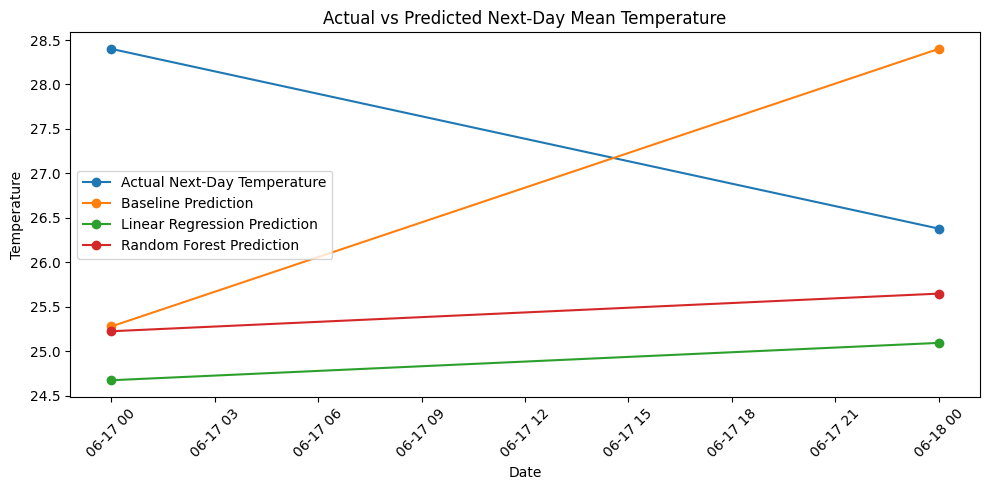

In [30]:
plt.figure(figsize=(10, 5))

plt.plot(
    test_dates,
    y_test.values,
    marker="o",
    label="Actual Next-Day Temperature"
)

plt.plot(
    test_dates,
    baseline_predictions.values,
    marker="o",
    label="Baseline Prediction"
)

plt.plot(
    test_dates,
    linear_predictions,
    marker="o",
    label="Linear Regression Prediction"
)

plt.plot(
    test_dates,
    rf_predictions,
    marker="o",
    label="Random Forest Prediction"
)

plt.title("Actual vs Predicted Next-Day Mean Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Save Actual vs Predicted Chart

The actual vs predicted temperature chart is saved as an image file in the `outputs/figures` folder.

This chart will be useful in the final report because it visually compares the baseline model, Linear Regression model, and Random Forest Regressor model.

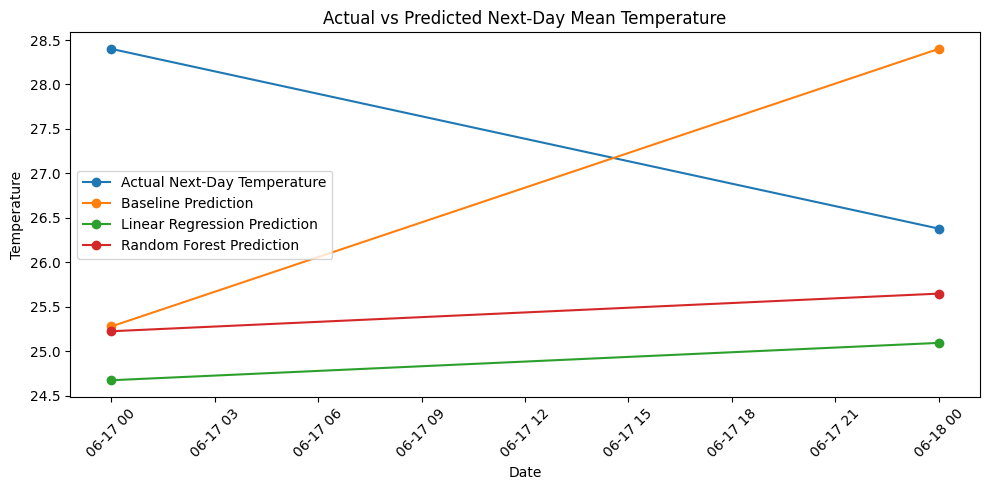

Actual vs predicted chart saved successfully.
Output file:
C:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Project_Weather_Forecast_Model\outputs\figures\actual_vs_predicted_temperature.png


In [31]:
# Define figures output folder
figures_dir = PROJECT_ROOT / "outputs" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

# Define output file path
actual_vs_predicted_file = figures_dir / "actual_vs_predicted_temperature.png"

plt.figure(figsize=(10, 5))

plt.plot(
    test_dates,
    y_test.values,
    marker="o",
    label="Actual Next-Day Temperature"
)

plt.plot(
    test_dates,
    baseline_predictions.values,
    marker="o",
    label="Baseline Prediction"
)

plt.plot(
    test_dates,
    linear_predictions,
    marker="o",
    label="Linear Regression Prediction"
)

plt.plot(
    test_dates,
    rf_predictions,
    marker="o",
    label="Random Forest Prediction"
)

plt.title("Actual vs Predicted Next-Day Mean Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.savefig(actual_vs_predicted_file, dpi=300)
plt.show()

print("Actual vs predicted chart saved successfully.")
print("Output file:")
print(actual_vs_predicted_file)

## Save the Best Forecasting Model

Based on the model comparison results, the Random Forest Regressor performed best for this prototype forecasting task.

In this step, we save the trained Random Forest model as a `.joblib` file in the `outputs/models` folder.

Saving the model allows it to be reused later without retraining.

In [32]:
import joblib

# Define models output folder
models_dir = PROJECT_ROOT / "outputs" / "models"
models_dir.mkdir(parents=True, exist_ok=True)

# Define model output file
best_model_file = models_dir / "best_weather_forecast_model_random_forest.joblib"

# Save the Random Forest model
joblib.dump(rf_model, best_model_file)

print("Best forecasting model saved successfully.")
print("Output file:")
print(best_model_file)

Best forecasting model saved successfully.
Output file:
C:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Project_Weather_Forecast_Model\outputs\models\best_weather_forecast_model_random_forest.joblib


## Final Summary

This notebook completed the first version of the Weather Forecasting Model project using Meteoblue API data.

The project workflow included:

1. Loading project configuration, location details, and API key
2. Extracting daily weather forecast data from the Meteoblue API
3. Saving the raw API response as JSON
4. Converting the daily weather data into a structured DataFrame
5. Cleaning and exporting the weather dataset
6. Performing exploratory analysis using temperature, precipitation, and correlation analysis
7. Creating a next-day average temperature forecasting target
8. Training and evaluating three forecasting approaches:
   - Baseline Previous Day Temperature Model
   - Linear Regression Model
   - Random Forest Regressor
9. Comparing model performance using MAE, RMSE, and MAPE
10. Saving the best-performing Random Forest model

Based on the prototype dataset, the Random Forest Regressor produced the best performance among the tested models.

Important note: this version uses a small 7-day Meteoblue forecast dataset, so the model should be considered a prototype. A future improvement will include collecting historical weather data to train and validate the model on a larger dataset.

In [33]:
print("Weather Forecasting Model Project - Notebook Completed")
print("------------------------------------------------------")
print("Best model: Random Forest Regressor")
print("Best model file:", best_model_file)
print("Model metrics file:", model_metrics_file)
print("Actual vs predicted chart:", actual_vs_predicted_file)

print("\nModel comparison:")
display(model_comparison_df)

Weather Forecasting Model Project - Notebook Completed
------------------------------------------------------
Best model: Random Forest Regressor
Best model file: C:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Project_Weather_Forecast_Model\outputs\models\best_weather_forecast_model_random_forest.joblib
Model metrics file: C:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Project_Weather_Forecast_Model\outputs\metrics\model_comparison_metrics.csv
Actual vs predicted chart: C:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Project_Weather_Forecast_Model\outputs\figures\actual_vs_predicted_temperature.png

Model comparison:


,model,MAE,RMSE,MAPE,MAPE_Percentage
0,Random Forest Regressor,1.952600,2.303142,0.069739,6.973927
1,Baseline Previous Day Temperature,2.570000,2.628193,0.093216,9.321616
2,Linear Regression,2.505027,2.786254,0.089938,8.993773
